In [1]:
import json
import matplotlib.pyplot as plt
from utils.plot_helpers import matplotlib_lhcb_style
import numpy as np

matplotlib_lhcb_style(plt)
plt.rcParams['text.usetex'] = False

Welcome to JupyROOT 6.20/06


In [2]:
names_dic = {
    'TaggingEfficiency': r'$\varepsilon_{\mathrm{tag}}$',
    'TaggingEfficiency_Cali': r'$\varepsilon^{\mathrm{cali}}_{\mathrm{tag}}$',
    'EffectiveMistag': r'$\omega$',
    'EffectiveMistag_Cali': r'$\omega^{\mathrm{cali}}$',
    'TaggingPower': r'$\varepsilon_{tag,\mathrm{eff}}$',
    'TaggingPower_Cali': r'$\varepsilon_{tag,\mathrm{eff}}^{\mathrm{cali}}$'
}

In [9]:
nom_f = '/work/celani/flavour_tagging/classical-taggers/savedModels/withUT_MC_2024/Bu2JpsiK/OSKaon/presel_PIDKonly/taggingInfo.json'
trueid_f = '/work/celani/flavour_tagging/classical-taggers/savedModels/withUT_MC_2024/Bu2JpsiK/OSKaon/presel_PIDKonly_TRUEID_NoGhost/taggingInfo.json'

with open(nom_f) as f:
    _nom = json.load(f)
with open(trueid_f) as f:
    _trueid = json.load(f)

In [10]:
for n in names_dic:
    print(n)
    print('Nominal', np.round(_nom[n][0],4), '+-', np.round(_nom[n][1],4))
    print('TRUEID', np.round(_trueid[n][0],4), '+-', np.round(_trueid[n][1],4), '\n')


TaggingEfficiency
Nominal 0.9095 +- 0.0026
TRUEID 0.9092 +- 0.0026 

TaggingEfficiency_Cali
Nominal 0.9095 +- 0.0026
TRUEID 0.9092 +- 0.0026 

EffectiveMistag
Nominal 0.4456 +- 0.0004
TRUEID 0.4596 +- 0.0003 

EffectiveMistag_Cali
Nominal 0.458 +- 0.0003
TRUEID 0.4666 +- 0.0003 

TaggingPower
Nominal 0.0108 +- 0.0002
TRUEID 0.0059 +- 0.0001 

TaggingPower_Cali
Nominal 0.0064 +- 0.0001
TRUEID 0.0041 +- 0.0001 



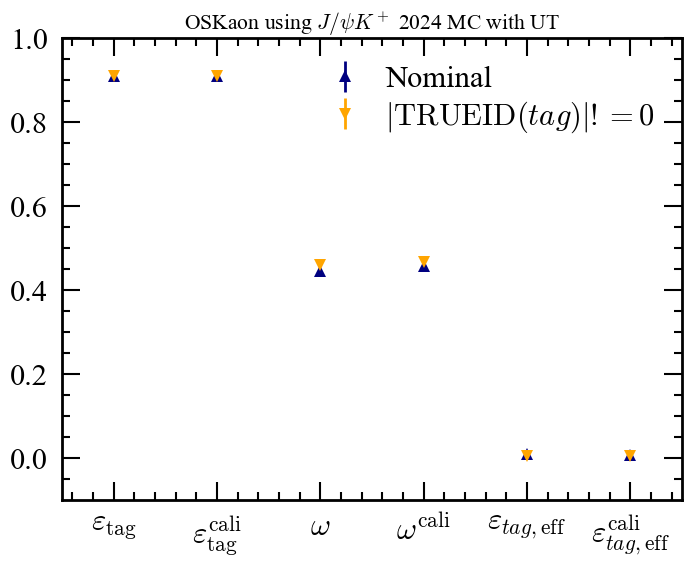

In [11]:
xvals = [n for n in names_dic.keys()]
x_names = [names_dic[n] for n in xvals]
yvals_nom = [_nom[k][0] for k in xvals]
yerr_nom = [_nom[k][1] for k in xvals]
yvals_trueid = [_trueid[k][0] for k in xvals]
yerr_trueid = [_trueid[k][1] for k in xvals]
plt.ylim(-0.1,1.0)
plt.xlim(0.,6.)
plt.errorbar(np.arange(len(xvals)) + 0.5, yvals_nom, yerr=yerr_nom, label='Nominal', fmt='^', color="navy", markersize=8)
# plt.errorbar(np.arange(len(xvals)) + 0.5, yvals_trueid, yerr=yerr_trueid, label=r'$|\mathrm{TRUEID}(tag)|=321$', fmt='v', color="orange", markersize=8)
plt.errorbar(np.arange(len(xvals)) + 0.5, yvals_trueid, yerr=yerr_trueid, label=r'$|\mathrm{TRUEID}(tag)|!=0$', fmt='v', color="orange", markersize=8)
plt.xticks(np.arange(len(xvals)) + 0.5, x_names)
plt.title('OSKaon using $J/\psi K^+$ 2024 MC with UT')
plt.legend(loc='best')
plt.show()
plt.close()